# BrushCue Example: Reef Current

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/reef_current.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/reef-current

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


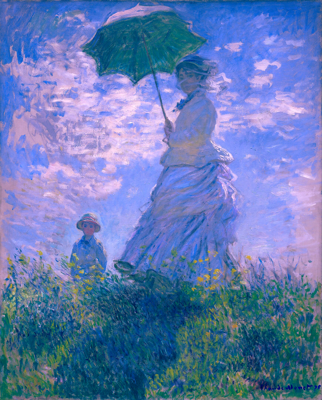

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
strength = 1.0
toned = (
    input_image.target_white_kelvin(6200.0)
    .chroma_offset(
        bc.Vector2f.from_components(((-0.02) * strength), ((-0.05) * strength))
    )
    .color_transformer_shader(
        "let highlight_weight = smoothstep(0.25, 0.75, input.r);\n  let tint = mix(shadow_tint, highlight_tint, highlight_weight) * amount;\n  return vec4<f32>(input.r, input.g + tint.x, input.b + tint.y, input.a);",
        "",
        bc.ColorRepresentation.oklab_a(),
        bc.ColorRepresentation.oklab_a(),
        bc.Dictionary.create()
        .add("amount", strength)
        .add("shadow_tint", bc.Vector2f.from_components((-0.05), (-0.03)))
        .add("highlight_tint", bc.Vector2f.from_components(0.06, 0.02)),
    )
    .saturation_adjust((1.0 + (0.25 * strength)))
)
glowed = toned.bloom(0.75, 18.0, 0.14)
bounds = input_image.bounds()
filtered = glowed.vignette(
    bc.Vector2f.from_components((bounds.width() / 2.0), (bounds.height() / 2.0)),
    (bounds.width() / 2.0),
    (bounds.height() / 2.0),
    300.0,
    0.2,
).crop(bounds)
graph = (
    filtered.opacity_scales(strength)
    .blend_alpha(input_image, bc.Transform2.identity())
    .crop(bounds)
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
